# 서울 좀비 바이러스 확산 시뮬레이션 - 데이터 정제 및 EDA

## 분석 목표
서울 도심에서 좀비 바이러스가 발생했을 때 생존 확률을 높일 수 있는 행동 전략을 데이터로 분석합니다.

## 논문 기반 모델 (Munz et al., 2009)
**SZR 기본 모델**
- **S** (Susceptible): 감수성자 → 초기 서울 생활인구
- **Z** (Zombie): 좀비 → 감염 확산
- **R** (Removed): 제거됨 (사망/격리)

**공간 데이터 → 모델 파라미터 매핑**
| 데이터 | 활용 | 모델 파라미터 |
|--------|------|--------|
| 250M 격자 생활인구 | 초기 감수성자 분포 | S₀ |
| 상권 밀집도 | 인구 접촉률 (음식점·소매) | β (감염률) ↑ |
| 지하철 승하차 인원 | 이동성·접촉 강도 | β 가중치 |
| 대피소 | 생존 거점, 접촉 감소 | β ↓, α(제거율) ↑ |
| 병의원 | 치료 거점 | c (치료율) |

---

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = '/Users/djs/Desktop/Toy_Project_Zombie/'

# KGD2002(EPSG:5179) → WGS84(EPSG:4326) 변환기
transformer = Transformer.from_crs('EPSG:5179', 'EPSG:4326', always_xy=True)

print('✅ 환경 설정 완료')
print(f'  geopandas: {gpd.__version__}')
print(f'  pandas: {pd.__version__}')

✅ 환경 설정 완료
  geopandas: 1.1.3
  pandas: 2.2.2


---
## 1. 데이터 로드 및 1차 정제

### 1-1. 서울특별시 250M 격자 생활인구 (S₀ - 초기 감수성자)

In [2]:
df_pop_raw = pd.read_csv(
    BASE_DIR + '서울특별시 250M격자 생활인구(내국인).csv',
    encoding='euc-kr'
)
print(f'원본 shape: {df_pop_raw.shape}')
print(f'일자: {df_pop_raw["일자"].unique()}')
print(f'시간: {sorted(df_pop_raw["시간"].unique())}')
print(f'격자 수: {df_pop_raw["250m격자"].nunique()}')
df_pop_raw.head(3)

원본 shape: (254411, 33)
일자: [20260312]
시간: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
격자 수: 8565


,일자,시간,행정동코드,250m격자,생활인구합계,남자 0~9세,남자 10~14세,남자 15~19세,남자 20~24세,남자 25~29세,...,여자 25~29세,여자 30~34세,여자 35~39세,여자 40~44세,여자 45~49세,여자 50~54세,여자 55~59세,여자 60~64세,여자 65~69세,여자 70세 이상
0,20260312,0,11110515,다사52255350,5.51,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
1,20260312,0,11110515,다사52255375,11.96,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
2,20260312,0,11110515,다사52505325,17.6,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*


In [3]:
# 생활인구합계 '*' → 0 처리 (개인정보 보호로 마스킹된 값)
df_pop_raw['생활인구합계'] = pd.to_numeric(df_pop_raw['생활인구합계'], errors='coerce').fillna(0)

# 격자 코드 디코딩 함수
# 공식: '다사AAAABBBB' → X = AAAA*10 + 900125, Y = BBBB*10 + 1900125 (KGD2002, EPSG:5179)
# 검증 완료: 기존 shp 데이터와 100% 일치
def decode_grid_code(code):
    """격자 코드 → KGD2002 중심 좌표 (X, Y)"""
    try:
        num = code[2:]  # 앞 2자리 한글 코드 제거
        x_code = int(num[:4])
        y_code = int(num[4:])
        x_kgd = x_code * 10 + 900125
        y_kgd = y_code * 10 + 1900125
        return x_kgd, y_kgd
    except:
        return None, None

# 격자별 시간대 피벗: 각 격자의 시간대별 생활인구
df_pop_pivot = df_pop_raw.pivot_table(
    index='250m격자', columns='시간', values='생활인구합계', aggfunc='sum'
).reset_index()
df_pop_pivot.columns = ['격자코드'] + [f'인구_{h}시' for h in sorted(df_pop_raw['시간'].unique())]

# 시간대별 주요 통계
hour_cols = [c for c in df_pop_pivot.columns if c.startswith('인구_')]
df_pop_pivot['인구_평균'] = df_pop_pivot[hour_cols].mean(axis=1)
df_pop_pivot['인구_최대'] = df_pop_pivot[hour_cols].max(axis=1)
df_pop_pivot['인구_최소'] = df_pop_pivot[hour_cols].min(axis=1)
# 좀비 시뮬레이션용: 낮 시간대(9-18시) 평균 = 활동 인구
daytime_cols = [f'인구_{h}시' for h in range(9, 19) if f'인구_{h}시' in df_pop_pivot.columns]
df_pop_pivot['인구_주간평균'] = df_pop_pivot[daytime_cols].mean(axis=1)
# 야간(0-6시) 평균 = 거주 인구
nighttime_cols = [f'인구_{h}시' for h in list(range(0, 6)) if f'인구_{h}시' in df_pop_pivot.columns]
df_pop_pivot['인구_야간평균'] = df_pop_pivot[nighttime_cols].mean(axis=1)

# 좌표 추출
coords = df_pop_pivot['격자코드'].apply(lambda c: pd.Series(decode_grid_code(c), index=['kgd_x', 'kgd_y']))
df_pop_pivot = pd.concat([df_pop_pivot, coords], axis=1)

# WGS84 변환
valid = df_pop_pivot['kgd_x'].notna()
lons, lats = transformer.transform(df_pop_pivot.loc[valid, 'kgd_x'].values,
                                    df_pop_pivot.loc[valid, 'kgd_y'].values)
df_pop_pivot.loc[valid, 'lon'] = lons
df_pop_pivot.loc[valid, 'lat'] = lats

# 유효 격자만 (서울 범위: lat 37.4~37.7, lon 126.7~127.2)
df_pop = df_pop_pivot[
    (df_pop_pivot['lon'] > 126.7) & (df_pop_pivot['lon'] < 127.2) &
    (df_pop_pivot['lat'] > 37.4) & (df_pop_pivot['lat'] < 37.7)
].copy()

print(f'정제 후 격자 수: {len(df_pop)}')
print(f'총 생활인구 (주간 평균): {df_pop["인구_주간평균"].sum():,.0f}명')
df_pop[['격자코드','lon','lat','인구_주간평균','인구_야간평균','인구_평균','인구_최대']].head()

정제 후 격자 수: 8564
총 생활인구 (주간 평균): 12,081,601명


,격자코드,lon,lat,인구_주간평균,인구_야간평균,인구_평균,인구_최대
0,다사35005075,126.765504,37.554940,9.373,0.000000,5.558750,10.02
1,다사35005100,126.765482,37.557193,0.000,0.000000,0.000000,0.00
2,다사35255050,126.768356,37.552704,16.136,5.488333,11.199583,17.24
3,다사35255075,126.768334,37.554958,121.277,41.300000,84.195833,129.60
4,다사35255100,126.768312,37.557211,62.055,21.143333,43.082917,66.32


### 1-2. 서울시 지진대피소 (대피 거점 - α 증가 지점)

In [4]:
df_shelter = pd.read_csv(BASE_DIR + '서울시 지진대피소 현황.csv', encoding='euc-kr')
print(f'원본 shape: {df_shelter.shape}')
print(f'컬럼: {list(df_shelter.columns)}')

# 정제
df_shelter = df_shelter.dropna(subset=['경도', '위도'])
df_shelter = df_shelter.rename(columns={'경도': 'lon', '위도': 'lat'})
df_shelter = df_shelter[(df_shelter['lon'] > 126.7) & (df_shelter['lat'] > 37.4)]

# 수용 면적을 수용 인원으로 변환 (1인당 3m² 기준)
df_shelter['수용인원추정'] = df_shelter['시설면적'] / 3

print(f'\n정제 후 대피소 수: {len(df_shelter)}')
print(f'총 수용 면적: {df_shelter["시설면적"].sum():,.0f} m²')
print(f'추정 총 수용 인원: {df_shelter["수용인원추정"].sum():,.0f}명')
print(f'구별 분포:')
print(df_shelter['시군구명'].value_counts())
df_shelter[['시설명','시군구명','lat','lon','시설면적','수용인원추정']].head()

원본 shape: (1551, 11)
컬럼: ['피난처 ID', '시도명', '시군구명', '시설명', '상세주소', '시설면적', '경도', '위도', '구분', '구분명', '관리부서']

정제 후 대피소 수: 1551
총 수용 면적: 8,770,040 m²
추정 총 수용 인원: 2,923,347명
구별 분포:
시군구명
강남구     120
강서구     116
송파구      90
양천구      84
관악구      80
노원구      79
영등포구     71
서초구      67
마포구      65
성북구      64
성동구      61
은평구      61
도봉구      55
강동구      54
중랑구      52
강북구      51
동대문구     50
구로구      47
금천구      47
서대문구     46
용산구      46
종로구      45
동작구      44
광진구      38
중구       18
Name: count, dtype: int64


,시설명,시군구명,lat,lon,시설면적,수용인원추정
0,동작고등학교 운동장,동작구,37.4820,126.9655,3246.0,1082.000000
1,동작초등학교 운동장,동작구,37.4940,126.9768,2763.0,921.000000
2,창림초등학교 운동장,도봉구,37.6431,127.0417,2584.0,861.333333
3,창원초등학교 운동장,도봉구,37.6521,127.0407,2704.0,901.333333
4,창일중학교 운동장,도봉구,37.6484,127.0471,4800.0,1600.000000


### 1-3. 서울시 병의원 위치 정보 (치료 거점 - c 파라미터)

In [5]:
df_hospital = pd.read_csv(
    BASE_DIR + '서울시 병의원 위치 정보.csv',
    encoding='cp949', on_bad_lines='skip'
)
print(f'원본 shape: {df_hospital.shape}')

df_hospital = df_hospital.rename(columns={'병원경도': 'lon', '병원위도': 'lat'})
df_hospital = df_hospital.dropna(subset=['lon', 'lat'])
df_hospital = df_hospital[
    (df_hospital['lon'] > 126.7) & (df_hospital['lon'] < 127.2) &
    (df_hospital['lat'] > 37.4) & (df_hospital['lat'] < 37.7)
]

# 응급 여부 플래그
df_hospital['응급가능'] = df_hospital['응급의료기관코드명'] != '응급의료기관 이외'

# 병원 규모별 가중치 (좀비 대응 능력)
hospital_weight = {
    '종합병원': 10, '병원': 5, '요양병원': 2,
    '의원': 1, '치과병원': 1, '치과의원': 0.5,
    '한방병원': 2, '한의원': 0.5, '보건소': 3, '기타': 1
}
df_hospital['치료가중치'] = df_hospital['병원분류명'].map(hospital_weight).fillna(1)

print(f'정제 후 병의원 수: {len(df_hospital)}')
print(f'응급 가능 기관: {df_hospital["응급가능"].sum()}개')
print(f'\n병원분류별:')
print(df_hospital['병원분류명'].value_counts())
df_hospital[['기관명','병원분류명','응급가능','치료가중치','lat','lon']].head()

원본 shape: (22156, 34)
정제 후 병의원 수: 22156
응급 가능 기관: 75개

병원분류별:
병원분류명
의원         11703
치과의원        5461
한의원         4291
병원           270
요양병원         140
한방병원         105
치과병원          66
종합병원          61
보건소           40
기타            18
기타(구급차)        1
Name: count, dtype: int64


,기관명,병원분류명,응급가능,치료가중치,lat,lon
0,가산기대찬의원,의원,False,1.0,37.480394,126.884122
1,365엠씨의원,의원,False,1.0,37.516604,127.021809
2,0236607779,의원,False,1.0,37.556989,126.859332
3,365더바른마취통증의학과의원,의원,False,1.0,37.619458,126.922920
4,가로수치과의원,치과의원,False,0.5,37.481918,126.929377


### 1-4. 서울시 지하철 승하차 인원 (이동성 지수 - β 가중치)

In [6]:
df_subway_raw = pd.read_csv(
    BASE_DIR + '서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv',
    encoding='euc-kr', on_bad_lines='skip'
)
print(f'원본 shape: {df_subway_raw.shape}')

# 시간대별 승하차 분리
ride_cols = [c for c in df_subway_raw.columns if '승차인원' in c]
alight_cols = [c for c in df_subway_raw.columns if '하차인원' in c]

df_subway_raw['총승차'] = df_subway_raw[ride_cols].sum(axis=1)
df_subway_raw['총하차'] = df_subway_raw[alight_cols].sum(axis=1)
df_subway_raw['총승하차'] = df_subway_raw['총승차'] + df_subway_raw['총하차']

# 주간 피크 (07-09, 18-20시)
peak_ride = ['07시-08시 승차인원', '08시-09시 승차인원', '18시-19시 승차인원', '19시-20시 승차인원']
peak_alight = ['07시-08시 하차인원', '08시-09시 하차인원', '18시-19시 하차인원', '19시-20시 하차인원']
avail_peak = [c for c in peak_ride + peak_alight if c in df_subway_raw.columns]
df_subway_raw['피크승하차'] = df_subway_raw[avail_peak].sum(axis=1)

# 역별 집계 (월평균 기준)
df_subway = df_subway_raw.groupby('지하철역').agg(
    총승하차=('총승하차', 'mean'),
    피크승하차=('피크승하차', 'mean'),
    호선수=('호선명', 'nunique')
).reset_index()

# 이동성 지수 정규화 (0~1)
df_subway['이동성지수'] = df_subway['총승하차'] / df_subway['총승하차'].max()

print(f'지하철역 수: {len(df_subway)}')
print(f'\nTop 10 이동성 높은 역:')
print(df_subway.sort_values('이동성지수', ascending=False)[
    ['지하철역','총승하차','피크승하차','이동성지수']
].head(10).to_string())
df_subway.head()

원본 shape: (79871, 52)
지하철역 수: 600

Top 10 이동성 높은 역:
            지하철역          총승하차         피크승하차     이동성지수
11            강남  5.179203e+06  1.552136e+06  1.000000
255           삼성  3.553734e+06  1.186501e+06  0.686155
62       구로디지털단지  3.432360e+06  1.306893e+06  0.662720
283        서울대입구  3.207124e+06  9.811230e+05  0.619231
256     삼성(무역센터)  3.110999e+06  1.064981e+06  0.600671
16            강변  3.081510e+06  8.721976e+05  0.594978
485           잠실  2.816767e+06  8.434600e+05  0.543861
406           역삼  2.805130e+06  1.045813e+06  0.541614
347           신림  2.783408e+06  9.353995e+05  0.537420
284  서울대입구(관악구청)  2.779129e+06  8.779810e+05  0.536594


,지하철역,총승하차,피크승하차,호선수,이동성지수
0,4.19민주묘지,1.817355e+05,50135.627451,1,0.035089
1,가능,3.975399e+05,127933.335821,1,0.076757
2,가락시장,4.951464e+05,161315.970149,2,0.095603
3,가산디지털단지,1.649895e+06,750538.007463,2,0.318562
4,가양,1.186061e+06,416935.007463,1,0.229005


### 1-5. 상권 정보 (감염 접촉률 지수 - β 공간 가중치)

In [7]:
# 대용량 파일: 필요 컬럼만 로드
df_biz = pd.read_csv(
    BASE_DIR + '소상공인시장진흥공단_상가(상권)정보_서울_202512.csv',
    encoding='utf-8', on_bad_lines='skip',
    usecols=['상권업종대분류명', '상권업종중분류명', '시군구명', '경도', '위도']
)
print(f'원본 shape: {df_biz.shape}')

df_biz = df_biz.rename(columns={'경도': 'lon', '위도': 'lat'})
df_biz = df_biz.dropna(subset=['lon', 'lat'])
df_biz = df_biz[
    (df_biz['lon'] > 126.7) & (df_biz['lon'] < 127.2) &
    (df_biz['lat'] > 37.4) & (df_biz['lat'] < 37.7)
]

# 좀비 시뮬레이션 접촉률 가중치 (사람 밀집도 기준)
# 음식점/소매/숙박 = 고접촉 (β 높음)
# 의료/교육 = 생존 자원
contact_weight = {
    '음식': 3.0,
    '소매': 2.5,
    '숙박': 2.0,
    '예술·스포츠': 2.0,
    '교육': 1.5,
    '보건의료': 1.0,
    '부동산': 0.5,
    '시설관리·임대': 0.5,
    '과학·기술': 0.3,
    '수리·개인': 1.5,
}
df_biz['접촉가중치'] = df_biz['상권업종대분류명'].map(contact_weight).fillna(1.0)

print(f'정제 후 상권 수: {len(df_biz)}')
print(f'\n업종 대분류별 분포:')
print(df_biz['상권업종대분류명'].value_counts())
df_biz.head(3)

원본 shape: (534978, 5)
정제 후 상권 수: 534978

업종 대분류별 분포:
상권업종대분류명
음식         135884
소매         111632
과학·기술       93261
수리·개인       51626
교육          45158
부동산         25059
시설관리·임대     24231
예술·스포츠      20446
보건의료        18840
숙박           8841
Name: count, dtype: int64


,상권업종대분류명,상권업종중분류명,시군구명,lon,lat,접촉가중치
0,음식,기타 간이,강동구,127.126859,37.550810,3.0
1,시설관리·임대,고용 알선,용산구,126.972240,37.552803,0.5
2,음식,비알코올,강서구,126.810493,37.563548,3.0


---
## 2. GeoDataFrame 생성

In [8]:
# 각 데이터셋 → GeoDataFrame
def to_gdf(df, lon_col='lon', lat_col='lat', crs='EPSG:4326'):
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs=crs)

gdf_pop      = to_gdf(df_pop)
gdf_shelter  = to_gdf(df_shelter)
gdf_hospital = to_gdf(df_hospital)
gdf_biz      = to_gdf(df_biz)

print('GeoDataFrame 생성 완료:')
print(f'  생활인구 격자:  {len(gdf_pop):,}개')
print(f'  지진대피소:     {len(gdf_shelter):,}개')
print(f'  병의원:         {len(gdf_hospital):,}개')
print(f'  상권:           {len(gdf_biz):,}개')

GeoDataFrame 생성 완료:
  생활인구 격자:  8,564개
  지진대피소:     1,551개
  병의원:         22,156개
  상권:           534,978개


---
## 3. 공간 조인 - 격자 기반 피처 엔지니어링

각 250m 격자에 대해 반경 내 자원(대피소, 병원, 상권)을 집계합니다.

In [9]:
from scipy.spatial import KDTree

# 좌표 배열
pop_coords    = np.array(list(zip(gdf_pop['lon'], gdf_pop['lat'])))
shelter_coords = np.array(list(zip(gdf_shelter['lon'], gdf_shelter['lat'])))
hospital_coords = np.array(list(zip(gdf_hospital['lon'], gdf_hospital['lat'])))
biz_coords    = np.array(list(zip(gdf_biz['lon'], gdf_biz['lat'])))

# 반경 500m ≈ 0.005° 위경도
RADIUS = 0.0045  # ~500m
SHELTER_RADIUS = 0.009  # ~1km (대피소는 더 넓은 범위)

# KD-Tree 구축
tree_shelter  = KDTree(shelter_coords)
tree_hospital = KDTree(hospital_coords)
tree_biz      = KDTree(biz_coords)

print('KD-Tree 구축 완료. 공간 집계 중...')

KD-Tree 구축 완료. 공간 집계 중...


In [10]:
# --- 대피소 집계 ---
# 각 격자 반경 1km 내: 대피소 수, 총 수용 면적, 최대 수용 면적
shelter_area = gdf_shelter['시설면적'].values
shelter_cap  = gdf_shelter['수용인원추정'].values

indices_s = tree_shelter.query_ball_point(pop_coords, r=SHELTER_RADIUS)
gdf_pop['대피소수_1km']   = [len(idx) for idx in indices_s]
gdf_pop['대피소면적합_1km'] = [shelter_area[idx].sum() if idx else 0 for idx in indices_s]
gdf_pop['대피소수용합_1km'] = [shelter_cap[idx].sum() if idx else 0 for idx in indices_s]

# 가장 가까운 대피소까지 거리 (도)
dist_s, _ = tree_shelter.query(pop_coords, k=1)
gdf_pop['최근대피소거리'] = dist_s * 111000  # 도 → 미터 (근사)

# --- 병원 집계 ---
hosp_weight = gdf_hospital['치료가중치'].values
hosp_emergency = gdf_hospital['응급가능'].astype(int).values

indices_h = tree_hospital.query_ball_point(pop_coords, r=RADIUS)
gdf_pop['병원수_500m']      = [len(idx) for idx in indices_h]
gdf_pop['병원가중치합_500m'] = [hosp_weight[idx].sum() if idx else 0 for idx in indices_h]
gdf_pop['응급병원수_500m']   = [hosp_emergency[idx].sum() if idx else 0 for idx in indices_h]

dist_h, _ = tree_hospital.query(pop_coords, k=1)
gdf_pop['최근병원거리'] = dist_h * 111000

# --- 상권 집계 (접촉률 지수) ---
biz_contact = gdf_biz['접촉가중치'].values

indices_b = tree_biz.query_ball_point(pop_coords, r=RADIUS)
gdf_pop['상권수_500m']      = [len(idx) for idx in indices_b]
gdf_pop['접촉지수_500m']    = [biz_contact[idx].sum() if idx else 0 for idx in indices_b]

print('공간 집계 완료!')
print(f'\n주요 통계:')
print(gdf_pop[['대피소수_1km','대피소수용합_1km','병원수_500m','상권수_500m','접촉지수_500m']].describe().round(2))

공간 집계 완료!

주요 통계:
       대피소수_1km  대피소수용합_1km  병원수_500m  상권수_500m  접촉지수_500m
count   8564.00     8564.00   8564.00   8564.00    8564.00
mean       6.95    12924.54     25.77    620.19    1115.59
std        4.30    16326.80     40.96    718.68    1212.45
min        0.00        0.00      0.00      0.00       0.00
25%        4.00     4047.58      1.00     92.00     164.52
50%        7.00     9080.17     12.00    403.00     743.70
75%       10.00    15604.83     36.00    885.00    1680.43
max       22.00   139012.00    600.00   6354.00    9421.80


---
## 4. 좀비 시뮬레이션 파라미터 계산

In [11]:
# SZR 모델 파라미터 공간화
# β (감염률): 상권 접촉지수 + 이동성 기반 가중치
# α (제거율): 대피소 접근성 기반
# S₀: 격자 생활인구

# β 기본값 (논문 기준: β = 0.0095)
BETA_BASE = 0.0095
ALPHA_BASE = 0.005

# β 공간 가중치: 접촉지수 정규화 (0.5 ~ 2.0 범위)
contact_norm = gdf_pop['접촉지수_500m'] / (gdf_pop['접촉지수_500m'].quantile(0.95) + 1e-9)
gdf_pop['beta_weight'] = 0.5 + 1.5 * contact_norm.clip(0, 1)
gdf_pop['beta'] = BETA_BASE * gdf_pop['beta_weight']

# α 공간 가중치: 대피소 접근성 (대피소 가까울수록 높음)
# 최근 대피소 거리: 500m 이내 = 최대 2배, 2000m 이상 = 0.5배
dist_factor = np.exp(-gdf_pop['최근대피소거리'] / 1000)  # 1km 감쇠
gdf_pop['alpha_weight'] = 0.5 + 1.5 * dist_factor
gdf_pop['alpha'] = ALPHA_BASE * gdf_pop['alpha_weight']

# 생존 가능성 지수 = α / β (높을수록 생존 유리)
gdf_pop['생존가능성지수'] = gdf_pop['alpha'] / gdf_pop['beta']

# 취약도 지수 = β / α (높을수록 위험)
gdf_pop['취약도지수'] = gdf_pop['beta'] / gdf_pop['alpha']

print('파라미터 계산 완료!')
print(f'\nβ (감염률) 분포:')
print(gdf_pop['beta'].describe().round(6))
print(f'\nα (제거율) 분포:')
print(gdf_pop['alpha'].describe().round(6))
print(f'\n생존가능성지수 분포:')
print(gdf_pop['생존가능성지수'].describe().round(4))

파라미터 계산 완료!

β (감염률) 분포:
count    8564.000000
mean        0.009090
std         0.004216
min         0.004750
25%         0.005427
50%         0.007809
75%         0.011663
max         0.019000
Name: beta, dtype: float64

α (제거율) 분포:
count    8564.000000
mean        0.007561
std         0.001448
min         0.002568
25%         0.006873
50%         0.007845
75%         0.008614
max         0.009986
Name: alpha, dtype: float64

생존가능성지수 분포:
count    8564.0000
mean        0.9642
std         0.3472
min         0.2858
25%         0.6804
50%         0.9471
75%         1.2375
max         2.0274
Name: 생존가능성지수, dtype: float64


---
## 5. EDA 시각화

### 5-1. 서울 250m 격자 생활인구 분포

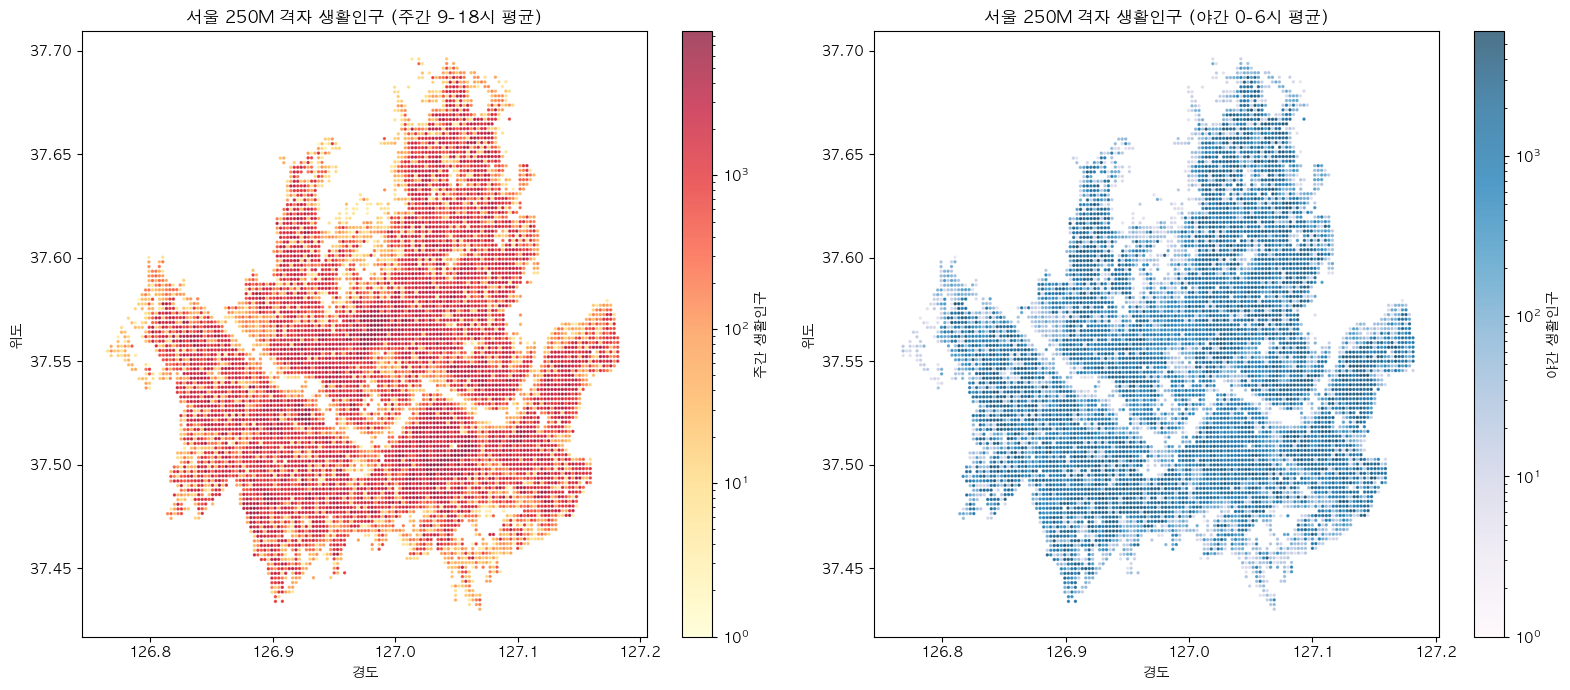

저장: eda_01_population.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 주간 인구
ax = axes[0]
sc = ax.scatter(
    gdf_pop['lon'], gdf_pop['lat'],
    c=gdf_pop['인구_주간평균'],
    cmap='YlOrRd', s=2, alpha=0.7,
    norm=mcolors.LogNorm(vmin=1, vmax=gdf_pop['인구_주간평균'].quantile(0.99)+1)
)
plt.colorbar(sc, ax=ax, label='주간 생활인구')
ax.set_title('서울 250M 격자 생활인구 (주간 9-18시 평균)', fontsize=12)
ax.set_xlabel('경도'); ax.set_ylabel('위도')

# 야간 인구
ax = axes[1]
sc = ax.scatter(
    gdf_pop['lon'], gdf_pop['lat'],
    c=gdf_pop['인구_야간평균'],
    cmap='PuBu', s=2, alpha=0.7,
    norm=mcolors.LogNorm(vmin=1, vmax=gdf_pop['인구_야간평균'].quantile(0.99)+1)
)
plt.colorbar(sc, ax=ax, label='야간 생활인구')
ax.set_title('서울 250M 격자 생활인구 (야간 0-6시 평균)', fontsize=12)
ax.set_xlabel('경도'); ax.set_ylabel('위도')

plt.tight_layout()
plt.savefig(BASE_DIR + 'eda_01_population.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: eda_01_population.png')

### 5-2. 시간대별 생활인구 변화 (S₀ 시계열)

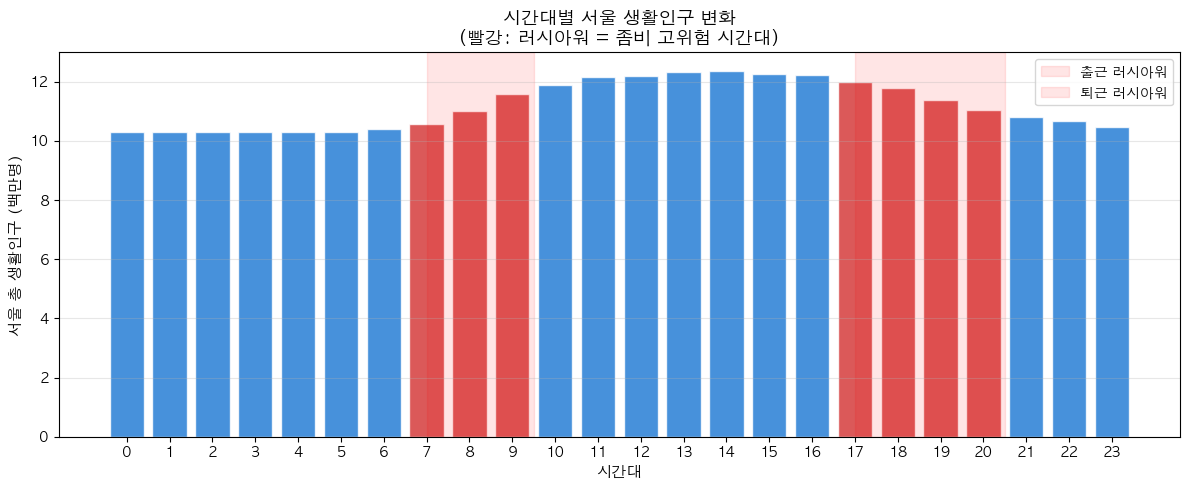

피크 시간: 14시, 인구: 12.37백만명


In [13]:
hour_total = []
for h in range(24):
    col = f'인구_{h}시'
    if col in gdf_pop.columns:
        hour_total.append({'시간': h, '총인구': gdf_pop[col].sum()})

df_hourly = pd.DataFrame(hour_total)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d32f2f' if 7 <= h <= 9 or 17 <= h <= 20 else '#1976d2' for h in df_hourly['시간']]
bars = ax.bar(df_hourly['시간'], df_hourly['총인구']/1e6, color=colors, alpha=0.8, edgecolor='white')
ax.set_xlabel('시간대', fontsize=11)
ax.set_ylabel('서울 총 생활인구 (백만명)', fontsize=11)
ax.set_title('시간대별 서울 생활인구 변화\n(빨강: 러시아워 = 좀비 고위험 시간대)', fontsize=13)
ax.set_xticks(range(24))
ax.grid(axis='y', alpha=0.3)

# 러시아워 설명
ax.axvspan(7, 9.5, alpha=0.1, color='red', label='출근 러시아워')
ax.axvspan(17, 20.5, alpha=0.1, color='red', label='퇴근 러시아워')
ax.legend()

plt.tight_layout()
plt.savefig(BASE_DIR + 'eda_02_hourly_population.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = df_hourly.loc[df_hourly['총인구'].idxmax()]
print(f'피크 시간: {int(peak_hour["시간"])}시, 인구: {peak_hour["총인구"]/1e6:.2f}백만명')

### 5-3. 감염 취약도 지도 (β/α 비율)

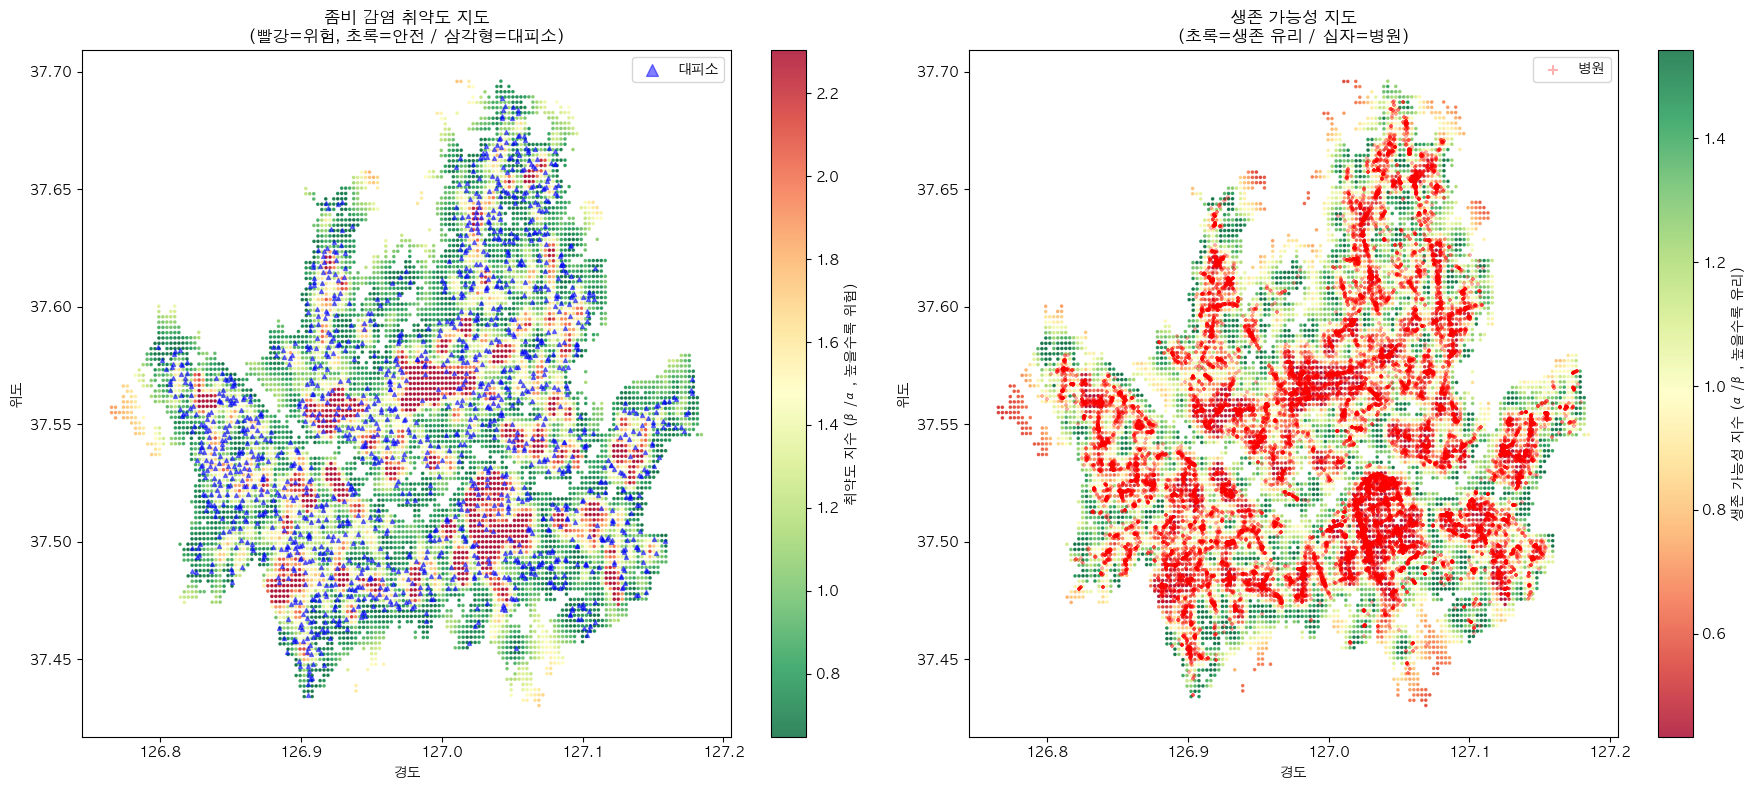

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 취약도 지수
ax = axes[0]
sc = ax.scatter(
    gdf_pop['lon'], gdf_pop['lat'],
    c=gdf_pop['취약도지수'],
    cmap='RdYlGn_r', s=2.5, alpha=0.8,
    vmin=gdf_pop['취약도지수'].quantile(0.05),
    vmax=gdf_pop['취약도지수'].quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='취약도 지수 (β/α, 높을수록 위험)')
# 대피소 표시
ax.scatter(gdf_shelter['lon'], gdf_shelter['lat'],
           c='blue', s=8, marker='^', alpha=0.5, label='대피소', zorder=5)
ax.set_title('좀비 감염 취약도 지도\n(빨강=위험, 초록=안전 / 삼각형=대피소)', fontsize=12)
ax.set_xlabel('경도'); ax.set_ylabel('위도')
ax.legend(markerscale=3)

# 생존가능성 지수
ax = axes[1]
sc = ax.scatter(
    gdf_pop['lon'], gdf_pop['lat'],
    c=gdf_pop['생존가능성지수'],
    cmap='RdYlGn', s=2.5, alpha=0.8,
    vmin=gdf_pop['생존가능성지수'].quantile(0.05),
    vmax=gdf_pop['생존가능성지수'].quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='생존 가능성 지수 (α/β, 높을수록 유리)')
ax.scatter(gdf_hospital['lon'], gdf_hospital['lat'],
           c='red', s=5, marker='+', alpha=0.3, label='병원', zorder=5)
ax.set_title('생존 가능성 지도\n(초록=생존 유리 / 십자=병원)', fontsize=12)
ax.set_xlabel('경도'); ax.set_ylabel('위도')
ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig(BASE_DIR + 'eda_03_vulnerability_map.png', dpi=150, bbox_inches='tight')
plt.show()

### 5-4. 구별 주요 지표 비교

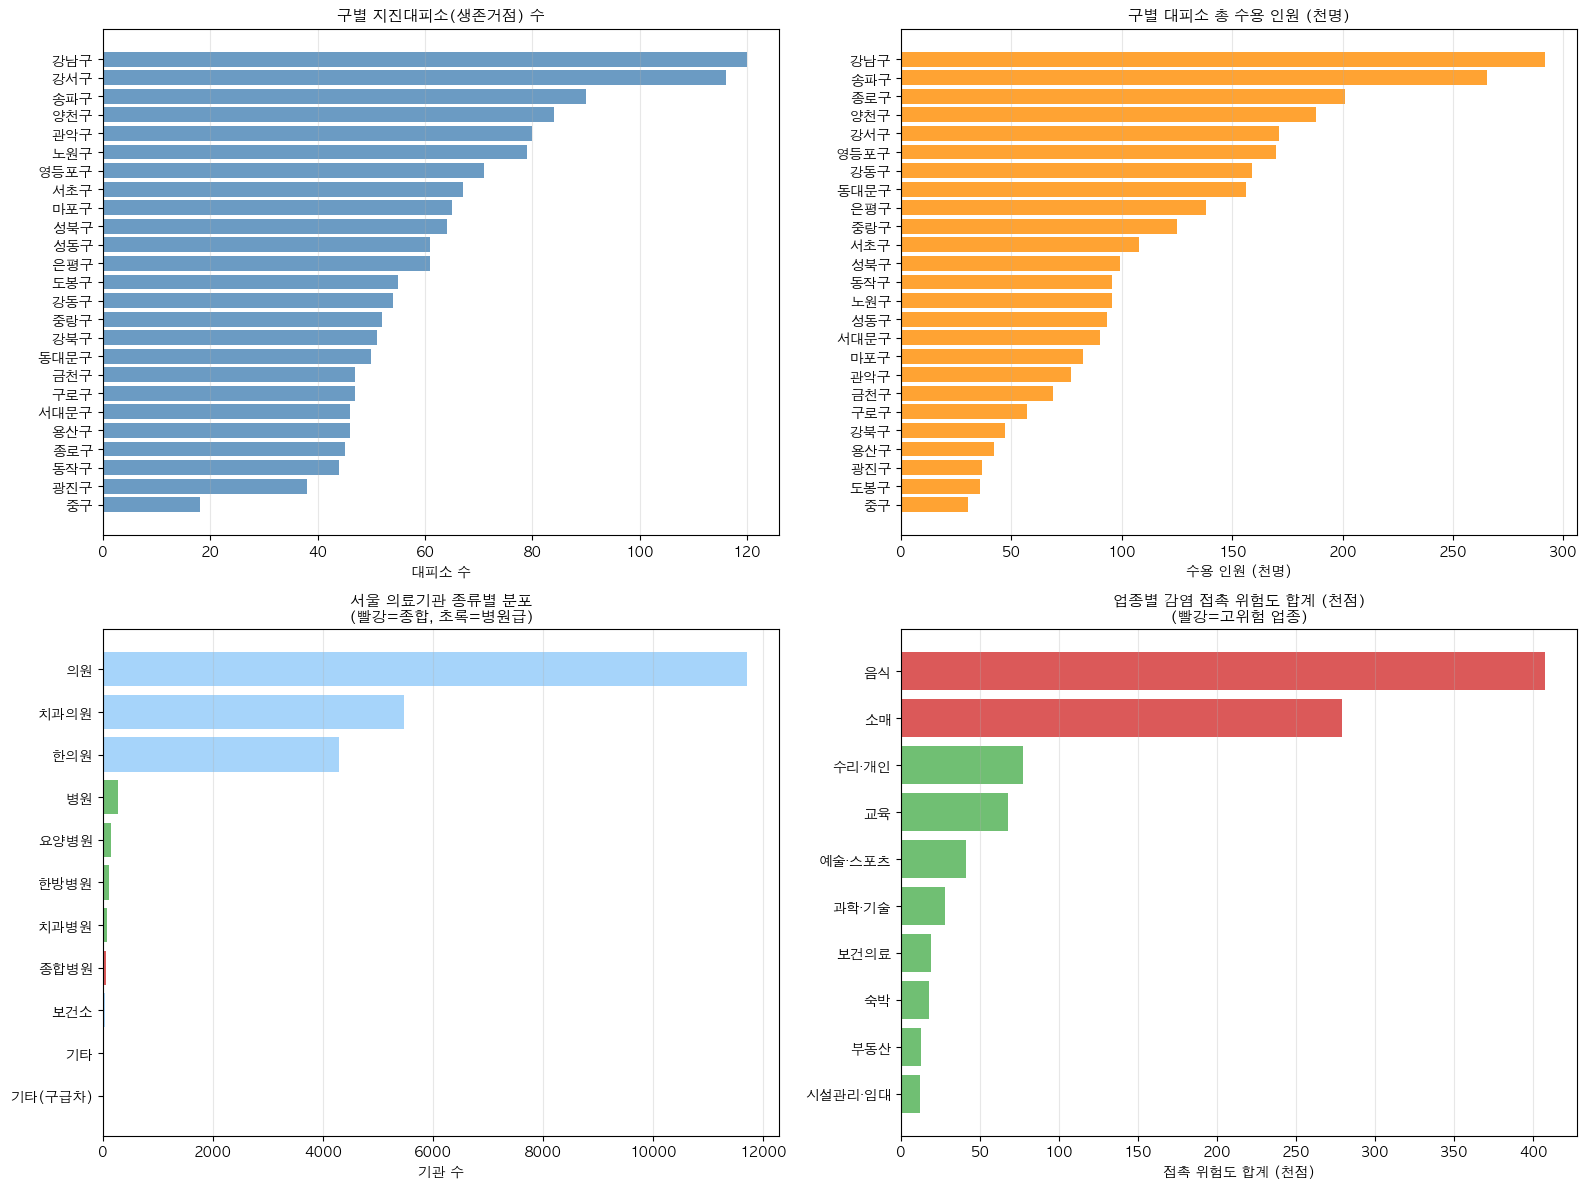

In [15]:
# 구별 대피소 현황
shelter_by_gu = df_shelter.groupby('시군구명').agg(
    대피소수=('시설명', 'count'),
    총수용면적=('시설면적', 'sum'),
    총수용인원=('수용인원추정', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 구별 대피소 수
ax = axes[0, 0]
s = shelter_by_gu.sort_values('대피소수', ascending=True)
ax.barh(s['시군구명'], s['대피소수'], color='steelblue', alpha=0.8)
ax.set_title('구별 지진대피소(생존거점) 수', fontsize=11)
ax.set_xlabel('대피소 수')
ax.grid(axis='x', alpha=0.3)

# 2. 구별 총 수용 인원
ax = axes[0, 1]
s = shelter_by_gu.sort_values('총수용인원', ascending=True)
ax.barh(s['시군구명'], s['총수용인원']/1000, color='darkorange', alpha=0.8)
ax.set_title('구별 대피소 총 수용 인원 (천명)', fontsize=11)
ax.set_xlabel('수용 인원 (천명)')
ax.grid(axis='x', alpha=0.3)

# 3. 구별 병원 수 (응급 vs 일반)
ax = axes[1, 0]
hosp_by_gu = df_hospital.groupby('병원분류명').size().sort_values(ascending=True)
colors_h = ['#d32f2f' if '종합' in i else '#4caf50' if '병원' in i else '#90caf9' for i in hosp_by_gu.index]
ax.barh(hosp_by_gu.index, hosp_by_gu.values, color=colors_h, alpha=0.8)
ax.set_title('서울 의료기관 종류별 분포\n(빨강=종합, 초록=병원급)', fontsize=11)
ax.set_xlabel('기관 수')
ax.grid(axis='x', alpha=0.3)

# 4. 업종별 접촉 위험도
ax = axes[1, 1]
biz_contact_by_cat = df_biz.groupby('상권업종대분류명').agg(
    업소수=('접촉가중치', 'count'),
    접촉지수합=('접촉가중치', 'sum')
).sort_values('접촉지수합', ascending=True)
colors_b = ['#d32f2f' if biz_contact_by_cat.loc[i, '접촉지수합']/biz_contact_by_cat.loc[i, '업소수'] > 2 
            else '#4caf50' for i in biz_contact_by_cat.index]
ax.barh(biz_contact_by_cat.index, biz_contact_by_cat['접촉지수합']/1000,
        color=colors_b, alpha=0.8)
ax.set_title('업종별 감염 접촉 위험도 합계 (천점)\n(빨강=고위험 업종)', fontsize=11)
ax.set_xlabel('접촉 위험도 합계 (천점)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR + 'eda_04_district_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5-5. 가장 위험한 구역 vs 가장 안전한 구역

🚨 위험 구역 (취약도 상위 5%)
   격자 수: 429
   평균 인구: 4482.7명
   평균 β: 0.018405
   평균 대피소 거리: 497m
   평균 상권 수: 2544.6개

✅ 안전 구역 (취약도 하위 5%)
   격자 수: 429
   평균 인구: 535.2명
   평균 α: 0.008628
   평균 대피소 거리: 207m
   평균 대피소 수 (1km): 6.4개


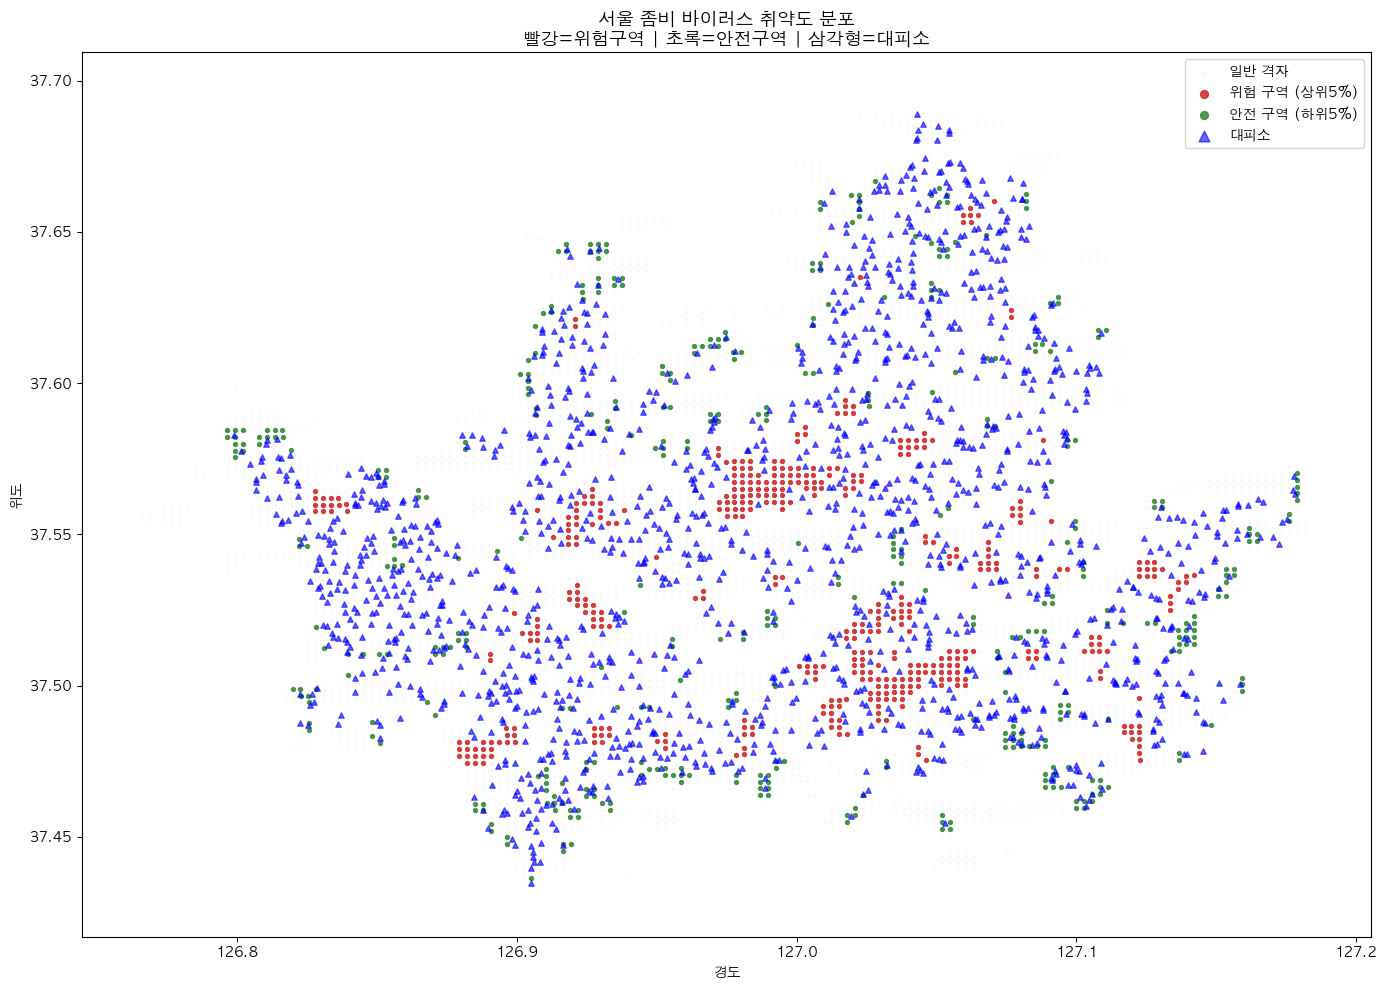

In [16]:
# 취약도 상위 5% 격자 (위험 구역)
danger_thresh = gdf_pop['취약도지수'].quantile(0.95)
safe_thresh   = gdf_pop['취약도지수'].quantile(0.05)

danger_zones = gdf_pop[gdf_pop['취약도지수'] >= danger_thresh]
safe_zones   = gdf_pop[gdf_pop['취약도지수'] <= safe_thresh]

print('=' * 60)
print('🚨 위험 구역 (취약도 상위 5%)')
print(f'   격자 수: {len(danger_zones)}')
print(f'   평균 인구: {danger_zones["인구_주간평균"].mean():.1f}명')
print(f'   평균 β: {danger_zones["beta"].mean():.6f}')
print(f'   평균 대피소 거리: {danger_zones["최근대피소거리"].mean():.0f}m')
print(f'   평균 상권 수: {danger_zones["상권수_500m"].mean():.1f}개')

print()
print('✅ 안전 구역 (취약도 하위 5%)')
print(f'   격자 수: {len(safe_zones)}')
print(f'   평균 인구: {safe_zones["인구_주간평균"].mean():.1f}명')
print(f'   평균 α: {safe_zones["alpha"].mean():.6f}')
print(f'   평균 대피소 거리: {safe_zones["최근대피소거리"].mean():.0f}m')
print(f'   평균 대피소 수 (1km): {safe_zones["대피소수_1km"].mean():.1f}개')

# 시각화
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(gdf_pop['lon'], gdf_pop['lat'], c='#eeeeee', s=1, alpha=0.3, label='일반 격자')
ax.scatter(danger_zones['lon'], danger_zones['lat'], c='#d32f2f', s=8, alpha=0.9, label='위험 구역 (상위5%)')
ax.scatter(safe_zones['lon'], safe_zones['lat'], c='#388e3c', s=8, alpha=0.9, label='안전 구역 (하위5%)')
ax.scatter(gdf_shelter['lon'], gdf_shelter['lat'], c='blue', s=15, marker='^', 
           alpha=0.6, label='대피소', zorder=5)

ax.set_title('서울 좀비 바이러스 취약도 분포\n빨강=위험구역 | 초록=안전구역 | 삼각형=대피소', fontsize=13)
ax.set_xlabel('경도'); ax.set_ylabel('위도')
ax.legend(markerscale=2, fontsize=10)

plt.tight_layout()
plt.savefig(BASE_DIR + 'eda_05_danger_safe_zones.png', dpi=150, bbox_inches='tight')
plt.show()

### 5-6. 지하철 이동성 vs 감염 위험도 상관관계

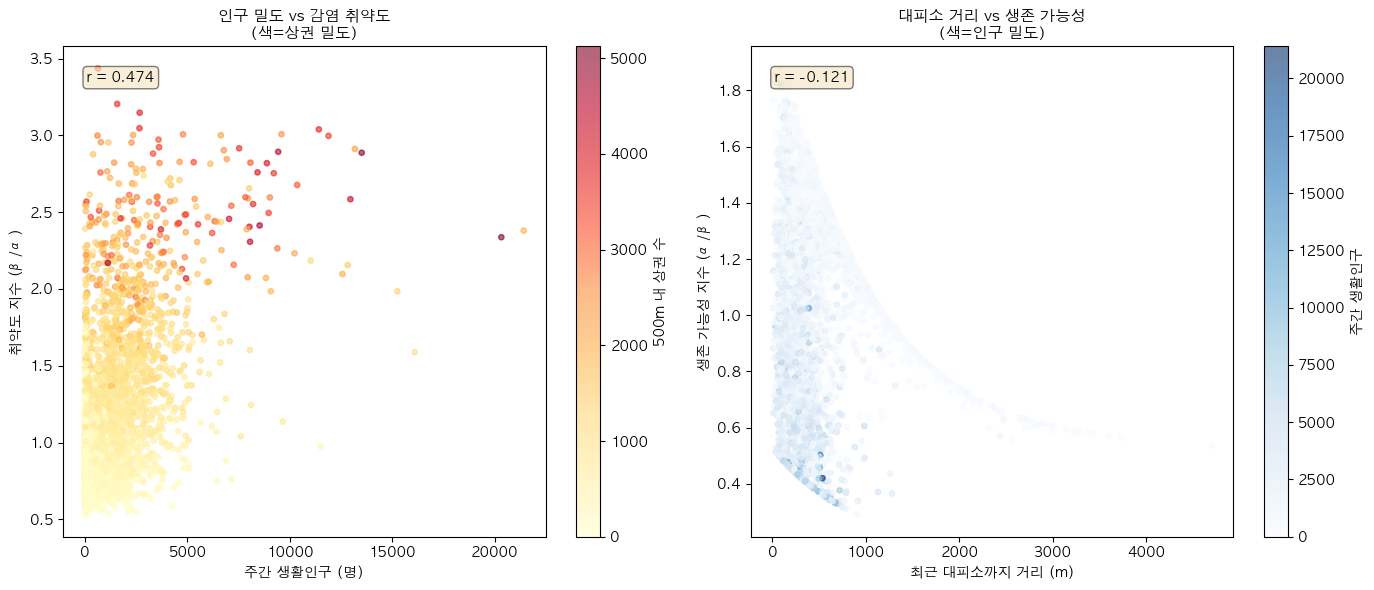

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 상관관계: 생활인구 vs 취약도
ax = axes[0]
sample = gdf_pop.sample(min(3000, len(gdf_pop)), random_state=42)
sc = ax.scatter(
    sample['인구_주간평균'], sample['취약도지수'],
    c=sample['상권수_500m'], cmap='YlOrRd',
    s=15, alpha=0.6
)
plt.colorbar(sc, ax=ax, label='500m 내 상권 수')
ax.set_xlabel('주간 생활인구 (명)')
ax.set_ylabel('취약도 지수 (β/α)')
ax.set_title('인구 밀도 vs 감염 취약도\n(색=상권 밀도)', fontsize=11)
corr = sample[['인구_주간평균', '취약도지수']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 대피소 거리 vs 생존 가능성
ax = axes[1]
sc = ax.scatter(
    sample['최근대피소거리'], sample['생존가능성지수'],
    c=sample['인구_주간평균'], cmap='Blues',
    s=15, alpha=0.6
)
plt.colorbar(sc, ax=ax, label='주간 생활인구')
ax.set_xlabel('최근 대피소까지 거리 (m)')
ax.set_ylabel('생존 가능성 지수 (α/β)')
ax.set_title('대피소 거리 vs 생존 가능성\n(색=인구 밀도)', fontsize=11)
corr2 = sample[['최근대피소거리', '생존가능성지수']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr2:.3f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(BASE_DIR + 'eda_06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. 최종 통합 데이터셋 저장

In [18]:
# 최종 격자 데이터셋 (EDA 완료)
# geometry 컬럼 제외하고 CSV 저장
keep_cols = [
    '격자코드', 'lon', 'lat',
    # 인구
    '인구_주간평균', '인구_야간평균', '인구_평균', '인구_최대',
    # 자원 접근성
    '대피소수_1km', '대피소면적합_1km', '대피소수용합_1km', '최근대피소거리',
    '병원수_500m', '병원가중치합_500m', '응급병원수_500m', '최근병원거리',
    '상권수_500m', '접촉지수_500m',
    # SZR 파라미터
    'beta', 'alpha', '생존가능성지수', '취약도지수'
]

# 일부 컬럼이 없을 경우 예외 처리
available_cols = [c for c in keep_cols if c in gdf_pop.columns]
df_final = gdf_pop[available_cols].copy()

output_path = BASE_DIR + 'zombie_grid_features.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'✅ 최종 데이터셋 저장: {output_path}')
print(f'   Shape: {df_final.shape}')
print(f'\n컬럼 목록:')
for c in df_final.columns:
    print(f'  - {c}: {df_final[c].dtype}')
df_final.head()

✅ 최종 데이터셋 저장: /Users/djs/Desktop/Toy_Project_Zombie/zombie_grid_features.csv
   Shape: (8564, 21)

컬럼 목록:
  - 격자코드: object
  - lon: float64
  - lat: float64
  - 인구_주간평균: float64
  - 인구_야간평균: float64
  - 인구_평균: float64
  - 인구_최대: float64
  - 대피소수_1km: int64
  - 대피소면적합_1km: float64
  - 대피소수용합_1km: float64
  - 최근대피소거리: float64
  - 병원수_500m: int64
  - 병원가중치합_500m: float64
  - 응급병원수_500m: int64
  - 최근병원거리: float64
  - 상권수_500m: int64
  - 접촉지수_500m: float64
  - beta: float64
  - alpha: float64
  - 생존가능성지수: float64
  - 취약도지수: float64


,격자코드,lon,lat,인구_주간평균,인구_야간평균,인구_평균,인구_최대,대피소수_1km,대피소면적합_1km,대피소수용합_1km,...,병원수_500m,병원가중치합_500m,응급병원수_500m,최근병원거리,상권수_500m,접촉지수_500m,beta,alpha,생존가능성지수,취약도지수
0,다사35005075,126.765504,37.554940,9.373,0.000000,5.558750,10.02,0,0.0,0.0,...,0,0.0,0,3513.975332,5,10.3,0.004792,0.002568,0.535945,1.865864
1,다사35005100,126.765482,37.557193,0.000,0.000000,0.000000,0.00,0,0.0,0.0,...,0,0.0,0,3469.240040,5,10.3,0.004792,0.002578,0.537868,1.859193
2,다사35255050,126.768356,37.552704,16.136,5.488333,11.199583,17.24,0,0.0,0.0,...,0,0.0,0,3275.589698,5,10.3,0.004792,0.002587,0.539766,1.852656
3,다사35255075,126.768334,37.554958,121.277,41.300000,84.195833,129.60,0,0.0,0.0,...,0,0.0,0,3208.012713,5,10.3,0.004792,0.002593,0.540997,1.848439
4,다사35255100,126.768312,37.557211,62.055,21.143333,43.082917,66.32,0,0.0,0.0,...,0,0.0,0,3158.848455,5,10.3,0.004792,0.002602,0.542923,1.841881


In [19]:
# EDA 요약 리포트
print('=' * 65)
print('     서울 좀비 바이러스 시뮬레이션 - EDA 요약 리포트')
print('=' * 65)
print()
print('[데이터 현황]')
print(f'  • 분석 격자 수:     {len(df_final):,}개 (250m × 250m)')
print(f'  • 서울 대피소:       {len(df_shelter):,}개')
print(f'  • 병의원:            {len(df_hospital):,}개 (응급 {df_hospital["응급가능"].sum()}개)')
print(f'  • 상권:              {len(df_biz):,}개')
print()
print('[좀비 S₀ - 초기 감수성자]')
print(f'  • 서울 총 주간 생활인구: {df_final["인구_주간평균"].sum():,.0f}명')
print(f'  • 서울 총 야간 생활인구: {df_final["인구_야간평균"].sum():,.0f}명')
print(f'  • 인구 밀집 격자 top5%: {df_final["인구_주간평균"].quantile(0.95):,.0f}명/격자 이상')
print()
print('[대피 자원 접근성]')
print(f'  • 대피소 없는 격자 (1km 기준): {(df_final["대피소수_1km"]==0).sum():,}개 '
      f'({(df_final["대피소수_1km"]==0).mean()*100:.1f}%)')
print(f'  • 평균 최근 대피소 거리:        {df_final["최근대피소거리"].mean():.0f}m')
print(f'  • 병원 없는 격자 (500m 기준):   {(df_final["병원수_500m"]==0).sum():,}개 '
      f'({(df_final["병원수_500m"]==0).mean()*100:.1f}%)')
print()
print('[SZR 파라미터 추정]')
print(f'  • β 평균 (감염률):  {df_final["beta"].mean():.6f}')
print(f'  • α 평균 (제거율):  {df_final["alpha"].mean():.6f}')
print(f'  • β/α > 1 격자 비율 (위험): {(df_final["취약도지수"]>1).mean()*100:.1f}%')
print()
print('[다음 단계]')
print('  → 격자별 SZR 시뮬레이션 (β, α 공간 가중치 적용)')
print('  → 대피 전략 비교: 무이동 vs 최근 대피소 이동 vs 병원 이동')
print('  → 시뮬레이션 결과 시각화 (감염 웨이브 애니메이션)')

     서울 좀비 바이러스 시뮬레이션 - EDA 요약 리포트

[데이터 현황]
  • 분석 격자 수:     8,564개 (250m × 250m)
  • 서울 대피소:       1,551개
  • 병의원:            22,156개 (응급 75개)
  • 상권:              534,978개

[좀비 S₀ - 초기 감수성자]
  • 서울 총 주간 생활인구: 12,081,601명
  • 서울 총 야간 생활인구: 10,306,598명
  • 인구 밀집 격자 top5%: 4,643명/격자 이상

[대피 자원 접근성]
  • 대피소 없는 격자 (1km 기준): 735개 (8.6%)
  • 평균 최근 대피소 거리:        463m
  • 병원 없는 격자 (500m 기준):   1,885개 (22.0%)

[SZR 파라미터 추정]
  • β 평균 (감염률):  0.009090
  • α 평균 (제거율):  0.007561
  • β/α > 1 격자 비율 (위험): 54.8%

[다음 단계]
  → 격자별 SZR 시뮬레이션 (β, α 공간 가중치 적용)
  → 대피 전략 비교: 무이동 vs 최근 대피소 이동 vs 병원 이동
  → 시뮬레이션 결과 시각화 (감염 웨이브 애니메이션)
